# Tutorial 1 — The moon signal, its sidebands, and the matched filter

What does an exomoon look like in the planet–star separation? Why is that signal
*not* a single sinusoid, and why does fitting the right physical model (the
projected-ellipse **matched filter**, Paper III Eq. 4) detect fainter moons than
a plain sine wave?

By the end you will be able to:

1. simulate one moon and inspect its separation residual,
2. read the periodogram and identify the planet-motion **sidebands**,
3. fit the same data with a single sinusoid and with the matched filter, and see
   where the sinusoid loses,
4. understand why the matched filter's detection cut must be **calibrated**.

Every tutorial has a `FAST` switch. `FAST = True` runs in minutes on a laptop;
`FAST = False` uses the exact configuration of the paper figure (slower).

## Setup

Run from the repository root (`python tutorials/01_signal_and_matched_filter.py`)
or open the `.ipynb`. Everything comes from the `exomoonsim` package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from exomoonsim.sim import SimParams, run_trial

FAST = True     # True: laptop-friendly (~1-2 min).  False: the Paper III Fig. 2 configuration.

if FAST:
    # coarser cadence + period grid, and 20 uas so the signal is obvious
    CFG = dict(astrometric_precision=2e-5, texp=6.0, pend=40.0, ptestwidth=0.003)
else:
    # paper: hourly cadence over 5 yr, 10 uas, fine period grid
    CFG = dict(astrometric_precision=1e-5, texp=1.0, pend=60.0, ptestwidth=0.0015)

UAS = 1e6                       # arcsec -> micro-arcsec
VIR = plt.get_cmap("viridis")

## 1. One moon, one campaign

`SimParams` describes the host system (the alpha Cen A giant-planet candidate by
default), the moon we inject, and the observing campaign. `run_trial` simulates
the campaign, fits and subtracts the planet's orbit about the star, and searches
the leftover **separation residual** for a periodic moon signal. With
`return_diagnostics=True` we get the residual time series back too.

We inject an Earth-mass moon at 20 Jupiter radii, inclined 60 degrees.

In [2]:
p = SimParams(moon_a=20.0, moon_mass=1.0, moon_inc=60.0, moon_ecc=0.0, **CFG)
r = run_trial(p, seed=3, return_diagnostics=True, recover_thr=1e12)   # huge thr: no subtraction
d = r["diag"]

td   = d["tdays"]                     # observation times (days)
rres = np.asarray(d["rres"])          # separation residual (arcsec) = the moon signal + noise
phi  = np.arctan2(d["y_fit"], d["x_fit"])   # planet position angle from the fitted orbit

print("true synodic period  = %.3f d" % d["true_synodic"])
print("true sidereal period = %.3f d" % d["moon_period"])
print("residual RMS         = %.1f uas   (noise per epoch = %.0f uas)"
      % (rres.std() * UAS, p.astrometric_precision * UAS))

true synodic period  = 20.529 d
true sidereal period = 20.062 d
residual RMS         = 46.8 uas   (noise per epoch = 20 uas)


The residual is dominated by the moon's reflex: the planet wobbles about the
planet–moon barycenter, and we see that wobble projected onto the star→planet
direction. Look at the first observing season:

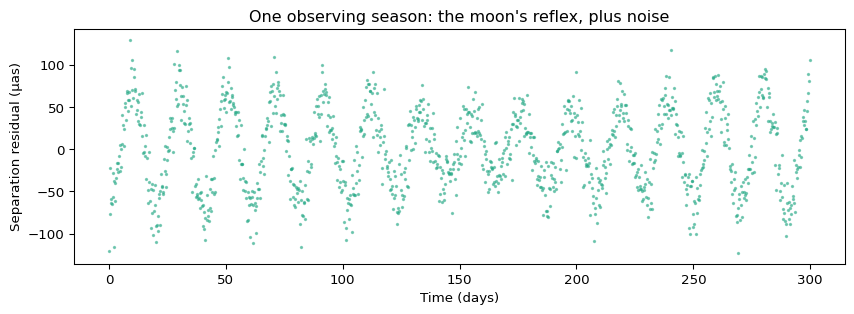

In [3]:
seg = td < 300
o = np.argsort(td[seg])
plt.figure(figsize=(9, 3.4))
plt.plot(td[seg][o], rres[seg][o] * UAS, ".", ms=3, color=VIR(0.6), alpha=0.5)
plt.xlabel("Time (days)"); plt.ylabel("Separation residual (µas)")
plt.title("One observing season: the moon's reflex, plus noise")
plt.tight_layout(); plt.show()

Notice the amplitude of the oscillation is **not constant** — it slowly waxes
and wanes. That is the whole story of this tutorial.

## 2. The periodogram and its sidebands

The search computes a detection significance at each trial period. The peak sits
at the moon's **synodic** period (its period as seen from the moving planet), and
it is flanked by two smaller lobes offset by exactly ±1/P_pl, the planet's
orbital frequency. These are **sidebands**: the star→planet direction rotates as
the planet orbits, which amplitude-modulates the moon signal and splits its
power into a carrier plus sidebands (Paper III §3.1).

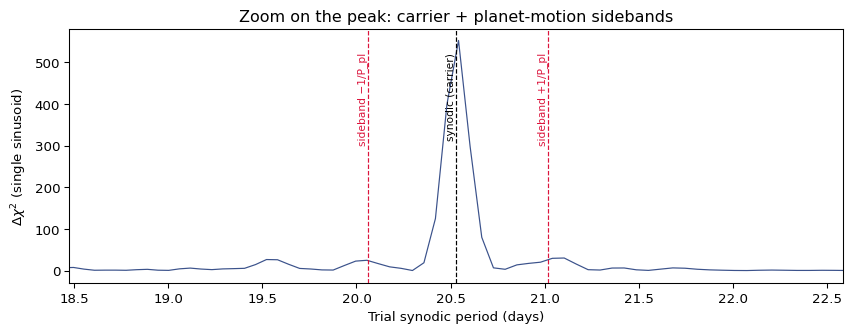

P_pl = 882 d;  sidebands expected at 20.06 and 21.02 d


In [4]:
P_pl = p.planet_period_yr() * 365.25          # planet orbital period (days)
P_syn, P_sid = d["true_synodic"], d["moon_period"]
f_syn = 1.0 / P_syn
side_lo, side_hi = 1.0 / (f_syn + 1.0 / P_pl), 1.0 / (f_syn - 1.0 / P_pl)

pg, sg = np.asarray(d["period_grid"]), np.asarray(d["periodogram"])
plt.figure(figsize=(9, 3.6))
plt.plot(pg, sg, color=VIR(0.25), lw=0.9)
for x, lab, c in [(P_syn, "synodic (carrier)", "k"), (side_lo, "sideband −1/P_pl", "crimson"),
                  (side_hi, "sideband +1/P_pl", "crimson")]:
    plt.axvline(x, color=c, ls="--", lw=0.9)
    plt.text(x, sg.max() * 0.95, lab, rotation=90, va="top", ha="right", fontsize=8, color=c)
plt.xlim(P_syn * 0.9, P_syn * 1.1)
plt.xlabel("Trial synodic period (days)"); plt.ylabel(r"$\Delta\chi^2$ (single sinusoid)")
plt.title("Zoom on the peak: carrier + planet-motion sidebands")
plt.tight_layout(); plt.show()
print("P_pl = %.0f d;  sidebands expected at %.2f and %.2f d" % (P_pl, side_lo, side_hi))

## 3. Single sinusoid vs. the matched filter

Papers I and II detected moons by fitting a **single sinusoid** at each trial
period: two free numbers (amplitude, phase) at one frequency — a constant-amplitude
tone. But we just saw the amplitude is modulated. The **matched filter** instead
fits the physical model of Paper III Eq. 4: the moon's 2-D sky reflex, at its
*sidereal* frequency ω, projected through the *known* planet position angle φ(t):

ρ(t) = cos(ωt)[a_x cos φ + a_y sin φ] + sin(ωt)[b_x cos φ + b_y sin φ] + const

It is linear in four coefficients, so it is an ordinary least-squares fit. Because
φ(t) rotates at the planet's frequency, multiplying by cos φ / sin φ automatically
generates the carrier **and** the sidebands — the template contains the modulation.
The same four coefficients are the projected reflex ellipse, whose axis ratio is
cos i, so one fit both detects and characterizes the moon.

In [5]:
def fit_sine(t, y, P):
    """Least-squares constant-amplitude sinusoid at period P (the Papers I/II model)."""
    w = 2 * np.pi / P
    G = np.column_stack([np.cos(w * t), np.sin(w * t), np.ones(t.size)])
    c = np.linalg.lstsq(G, y, rcond=None)[0]
    return G @ c, c

def fit_ellipse(t, y, phi, P_sid):
    """Least-squares projected-ellipse matched filter at sidereal period P_sid (Paper III Eq. 4)."""
    w = 2 * np.pi / P_sid
    G = np.column_stack([np.cos(w * t) * np.cos(phi), np.cos(w * t) * np.sin(phi),
                         np.sin(w * t) * np.cos(phi), np.sin(w * t) * np.sin(phi), np.ones(t.size)])
    c = np.linalg.lstsq(G, y, rcond=None)[0]
    ax_, ay_, bx_, by_ = c[:4]
    # local amplitude envelope sqrt(C^2 + S^2) of the modulated signal
    C = ax_ * np.cos(phi) + ay_ * np.sin(phi); S = bx_ * np.cos(phi) + by_ * np.sin(phi)
    return G @ c, np.hypot(C, S)

m_sine, _   = fit_sine(td, rres, P_syn)          # sinusoid lives at the synodic carrier
m_ell, env  = fit_ellipse(td, rres, phi, P_sid)  # matched filter at the moon's sidereal period
rms = lambda m: np.sqrt(np.mean((rres - m) ** 2)) * UAS
print("residual RMS after fit:  single sinusoid = %5.1f uas   matched filter = %5.1f uas   (noise = %.0f uas)"
      % (rms(m_sine), rms(m_ell), p.astrometric_precision * UAS))

residual RMS after fit:  single sinusoid =  29.4 uas   matched filter =  20.1 uas   (noise = 20 uas)


The matched filter reaches the photon-noise floor; the sinusoid leaves power
behind. Now see *where* it loses — over one season, and in the phase-fold:

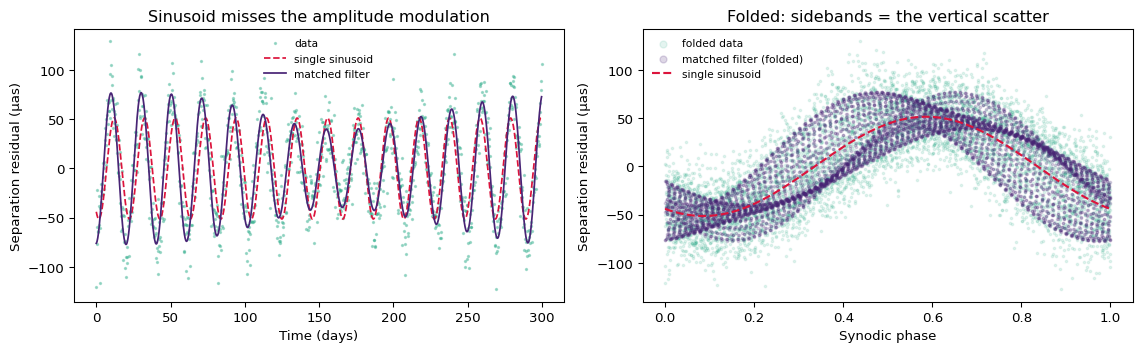

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(td[seg][o], rres[seg][o] * UAS, ".", ms=3, color=VIR(0.6), alpha=0.35, label="data")
ax[0].plot(td[seg][o], m_sine[seg][o] * UAS, "--", color="crimson", lw=1.3, label="single sinusoid")
ax[0].plot(td[seg][o], m_ell[seg][o] * UAS, "-", color=VIR(0.1), lw=1.3, label="matched filter")
ax[0].set_xlabel("Time (days)"); ax[0].set_ylabel("Separation residual (µas)")
ax[0].set_title("Sinusoid misses the amplitude modulation"); ax[0].legend(fontsize=8, frameon=False)

ph = (td % P_syn) / P_syn
ax[1].scatter(ph, rres * UAS, s=3, color=VIR(0.6), alpha=0.12, label="folded data")
ax[1].scatter(ph, m_ell * UAS, s=3, color=VIR(0.1), alpha=0.18, label="matched filter (folded)")
pg2 = np.linspace(0, 1, 300)
_, cs = fit_sine(td, rres, P_syn)
ax[1].plot(pg2, (cs[0] * np.cos(2 * np.pi * pg2) + cs[1] * np.sin(2 * np.pi * pg2) + cs[2]) * UAS,
           "--", color="crimson", lw=1.6, label="single sinusoid")
ax[1].set_xlabel("Synodic phase"); ax[1].set_ylabel("Separation residual (µas)")
ax[1].set_title("Folded: sidebands = the vertical scatter"); ax[1].legend(fontsize=8, frameon=False, markerscale=3)
plt.tight_layout(); plt.show()

Folded at the synodic period the data form a **band**, not a curve — the width
of that band is the sideband power. The sinusoid can only draw a curve through
the middle; the matched filter reproduces the band.

## 4. The amplitude envelope over the whole campaign

The modulation runs on the planet's orbital period: the signal amplitude beats
between the face-on reflex amplitude and cos i times it, as the star→planet
direction sweeps around. The matched-filter envelope tracks it; the sinusoid is a
flat line.

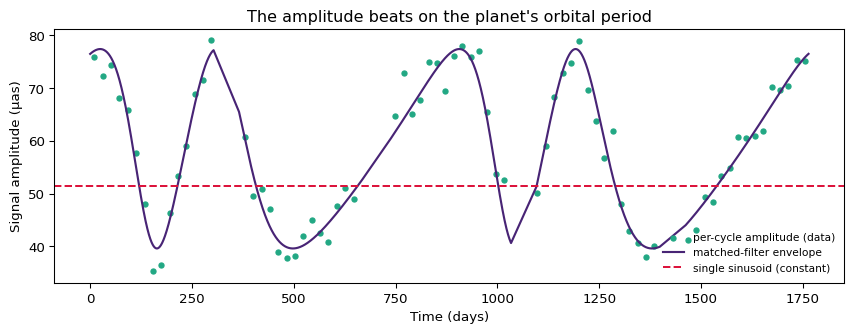

In [7]:
def per_cycle_amp(t, y, P):
    """Local sinusoid amplitude fitted within each synodic cycle (noise-unbiased)."""
    edges = np.arange(t.min(), t.max() + P, P); tc, ac = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (t >= lo) & (t < hi)
        if m.sum() >= 0.6 * P * 24.0 / p.texp:           # only well-sampled cycles
            _, c = fit_sine(t[m], y[m], P); tc.append(0.5 * (lo + hi)); ac.append(np.hypot(c[0], c[1]))
    return np.array(tc), np.array(ac)

tc, ac = per_cycle_amp(td, rres, P_syn)
_, cs = fit_sine(td, rres, P_syn)
oo = np.argsort(td)
plt.figure(figsize=(9, 3.6))
plt.scatter(tc, ac * UAS, s=14, color=VIR(0.6), label="per-cycle amplitude (data)")
plt.plot(td[oo], env[oo] * UAS, color=VIR(0.1), lw=1.6, label="matched-filter envelope")
plt.axhline(np.hypot(cs[0], cs[1]) * UAS, ls="--", color="crimson", label="single sinusoid (constant)")
plt.xlabel("Time (days)"); plt.ylabel("Signal amplitude (µas)")
plt.title("The amplitude beats on the planet's orbital period"); plt.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 5. Using the matched filter to *detect*: the calibrated cut

Evaluated across a grid of trial periods, the matched-filter fit becomes a
detection statistic — the search picks the period with the largest drop in χ².
One subtlety: the single-sinusoid statistic is a *reduced* χ², while the
matched filter's is a *raw* four-degree-of-freedom χ², so they live on different
scales and the Papers I/II threshold (Δχ² > 5) cannot be reused directly.

The cut is therefore **calibrated**: run zero-signal (moon-free) trials through
the identical search with both statistics, measure how often the sinusoid's
Δχ² > 5 fires on pure noise, and set the matched-filter threshold that fires at
the same rate. For the paper's searches that lands at Δχ²_mf ≈ 26–29. Tutorial 2
performs this calibration and uses the matched filter to recover a four-moon
system. Try it below on the single moon: the statistic is `stat="ellipse"`.

In [8]:
r_sine = run_trial(p, seed=3, stat="sine")
r_ell  = run_trial(p, seed=3, stat="ellipse")
print("search peak:  single sinusoid dchi = %8.1f at P = %.2f d" % (r_sine["sig"], r_sine["best_period"]))
print("              matched filter dchi = %8.1f at P = %.2f d   (different scale -- see calibration)"
      % (r_ell["sig"], r_ell["best_period"]))

search peak:  single sinusoid dchi =    552.3 at P = 20.54 d
              matched filter dchi =  26708.5 at P = 20.54 d   (different scale -- see calibration)


## Take-aways

* The moon signal is a carrier at the synodic period **plus sidebands** at ±1/P_pl,
  because the planet's motion modulates the projection.
* A single sinusoid fits only the carrier and discards the sideband power; the
  matched filter (Eq. 4) contains the modulation and reaches the noise floor.
* The advantage grows for wider, longer-period moons (more planet motion per orbit),
  which is why the paper finds a much stronger separation lever with the matched filter.
* The matched-filter cut must be calibrated to a false-alarm rate — Tutorial 2.

**Scaling to the paper:** set `FAST = False` to use hourly cadence at 10 µas
(Paper III Fig. 2). Change `moon_a` to 50 to see the wider-moon case.